In [1]:
import pandas as pd
import os
df = pd.read_csv("train.csv")
df.head()

,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,...,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,...,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0
1,1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,...,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0
2,2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,...,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0
3,3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,...,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0
4,4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,...,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0


In [2]:
df.set_index("id",inplace=True)

In [3]:
pd.set_option("display.max_columns",None)

In [4]:
df.head()

,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
id,,,,,,,,,,,,,,,,,,,,
0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,Premium,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0
1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,Comprehensive,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0
2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,Premium,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0
3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,Basic,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0
4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,Premium,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0


In [5]:
df.columns

Index(['Age', 'Gender', 'Annual Income', 'Marital Status',
       'Number of Dependents', 'Education Level', 'Occupation', 'Health Score',
       'Location', 'Policy Type', 'Previous Claims', 'Vehicle Age',
       'Credit Score', 'Insurance Duration', 'Policy Start Date',
       'Customer Feedback', 'Smoking Status', 'Exercise Frequency',
       'Property Type', 'Premium Amount'],
      dtype='object')

In [6]:
df.isnull().sum()

Age                      18705
Gender                       0
Annual Income            44949
Marital Status           18529
Number of Dependents    109672
Education Level              0
Occupation              358075
Health Score             74076
Location                     0
Policy Type                  0
Previous Claims         364029
Vehicle Age                  6
Credit Score            137882
Insurance Duration           1
Policy Start Date            0
Customer Feedback        77824
Smoking Status               0
Exercise Frequency           0
Property Type                0
Premium Amount               0
dtype: int64

In [7]:
from category_encoders import TargetEncoder
tar = TargetEncoder()

In [8]:
df["Policy Start Date"] = pd.to_datetime(df["Policy Start Date"],format="%Y-%m-%d %H:%M:%S.%f")

In [9]:
df["Year"] = df["Policy Start Date"].dt.year
df["Month"] = df["Policy Start Date"].dt.month
df["Day"] = df["Policy Start Date"].dt.day
df["Week"] = df["Policy Start Date"].dt.isocalendar().week
df["Num_of_week"]=df["Policy Start Date"].dt.day_of_week
df["Hour"] = df["Policy Start Date"].dt.hour
df["Minute"] = df["Policy Start Date"].dt.minute

In [10]:
df.drop("Policy Start Date",axis=1,inplace=True)

In [11]:
impute_values = {
    "Age": df["Age"].median(),
    "Annual Income": df["Annual Income"].median(),
    "Marital Status": df["Marital Status"].mode()[0],
    "Number of Dependents": df["Number of Dependents"].median(),
    "Occupation": df["Occupation"].mode()[0],
    "Health Score": df["Health Score"].median(),
    "Previous Claims": df["Previous Claims"].median(),
    "Vehicle Age": df["Vehicle Age"].median(),
    "Credit Score": df["Credit Score"].median(),
    "Insurance Duration": df["Insurance Duration"].median(),
    "Customer Feedback" : df["Customer Feedback"].mode()[0]
}

In [12]:
df.fillna(impute_values, inplace=True)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
import numpy as np

In [15]:
from category_encoders import TargetEncoder
encoders = {}

cols = ["Gender","Marital Status","Education Level","Occupation",
        "Location","Policy Type","Customer Feedback",
        "Smoking Status","Exercise Frequency","Property Type"]

for col in cols:
    tar = TargetEncoder()
    df[col] = tar.fit_transform(df[col],df[col])
    encoders[col] = tar

In [16]:
df.head()

,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount,Year,Month,Day,Week,Num_of_week,Hour,Minute
id,,,,,,,,,,,,,,,,,,,,,,,,,,
0,19.0,0.0,10049.0,1.0,1.0,0.0,1.0,22.598761,2.0,2.0,2.0,17.0,372.0,5.0,2.0,0.0,3.0,2.0,2869.0,2023,12,23,51,5,15,21
1,39.0,0.0,31678.0,0.0,3.0,2.0,0.0,15.569731,0.0,1.0,1.0,12.0,694.0,2.0,0.0,1.0,1.0,2.0,1483.0,2023,6,12,24,0,15,21
2,23.0,1.0,25602.0,0.0,3.0,1.0,1.0,47.177549,1.0,2.0,1.0,14.0,595.0,3.0,1.0,1.0,3.0,2.0,567.0,2023,9,30,39,5,15,21
3,21.0,1.0,141855.0,1.0,2.0,0.0,0.0,10.938144,0.0,0.0,1.0,0.0,367.0,1.0,2.0,1.0,0.0,0.0,765.0,2024,6,12,24,2,15,21
4,21.0,1.0,39651.0,2.0,1.0,0.0,1.0,20.376094,0.0,2.0,0.0,8.0,598.0,4.0,2.0,1.0,3.0,2.0,2022.0,2021,12,1,48,2,15,21


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1200000 entries, 0 to 1199999
Data columns (total 26 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   Age                   1200000 non-null  float64
 1   Gender                1200000 non-null  float64
 2   Annual Income         1200000 non-null  float64
 3   Marital Status        1200000 non-null  float64
 4   Number of Dependents  1200000 non-null  float64
 5   Education Level       1200000 non-null  float64
 6   Occupation            1200000 non-null  float64
 7   Health Score          1200000 non-null  float64
 8   Location              1200000 non-null  float64
 9   Policy Type           1200000 non-null  float64
 10  Previous Claims       1200000 non-null  float64
 11  Vehicle Age           1200000 non-null  float64
 12  Credit Score          1200000 non-null  float64
 13  Insurance Duration    1200000 non-null  float64
 14  Customer Feedback     1200000 non-null 

In [18]:
df.corr()

,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount,Year,Month,Day,Week,Num_of_week,Hour,Minute
Age,1.000000,0.000215,0.000061,0.000225,0.001399,-0.000416,0.001394,0.000813,0.001861,-0.000407,0.001544,-0.002436,0.002661,-0.000062,0.000273,-0.000628,0.000421,-0.001176,-0.002410,-0.003151,0.001196,-0.000596,0.000990,-0.001221,NaN,NaN
Gender,0.000215,1.000000,-0.000983,0.001285,0.000833,0.000558,0.000472,0.003412,0.001225,-0.001539,-0.000229,0.000949,0.000756,0.000266,0.000533,0.003187,-0.000568,-0.000994,0.000161,0.000446,0.001254,0.000557,0.001179,0.000016,NaN,NaN
Annual Income,0.000061,-0.000983,1.000000,0.004035,0.001920,0.000257,0.003371,0.023301,0.000434,-0.000843,0.034777,-0.000438,-0.181180,0.000383,-0.015830,-0.001492,0.001439,-0.000462,-0.009989,-0.009716,0.008825,0.000346,0.008318,0.000143,NaN,NaN
Marital Status,0.000225,0.001285,0.004035,1.000000,-0.000658,-0.000986,0.002385,0.001610,0.000519,0.000155,0.000242,0.001132,-0.002786,-0.000510,0.000781,-0.000266,-0.000247,-0.003362,0.003021,0.001594,-0.000903,0.002019,-0.000978,-0.000430,NaN,NaN
Number of Dependents,0.001399,0.000833,0.001920,-0.000658,1.000000,0.000340,-0.001255,0.004831,-0.000347,-0.001181,-0.003277,0.001170,-0.001525,-0.000252,-0.000994,0.000598,-0.000471,0.002104,-0.000947,0.000358,-0.000443,0.000200,0.000162,-0.000928,NaN,NaN
Education Level,-0.000416,0.000558,0.000257,-0.000986,0.000340,1.000000,0.000596,0.001360,0.002941,0.001344,0.000245,0.000743,-0.002020,0.000575,0.001136,0.000424,0.001498,0.001245,-0.001121,0.000349,0.000176,-0.002491,-0.000010,0.001738,NaN,NaN
Occupation,0.001394,0.000472,0.003371,0.002385,-0.001255,0.000596,1.000000,0.002396,0.001271,-0.000507,0.002132,0.000984,-0.004570,0.001421,-0.001850,-0.000701,-0.001754,-0.003419,0.003185,0.000914,0.001428,0.001719,0.001566,0.000883,NaN,NaN
Health Score,0.000813,0.003412,0.023301,0.001610,0.004831,0.001360,0.002396,1.000000,-0.002067,-0.002296,0.001779,0.000237,0.009947,0.002374,-0.001380,-0.002050,-0.000748,-0.001030,0.013976,-0.001667,0.000603,-0.000586,0.000729,0.000008,NaN,NaN
Location,0.001861,0.001225,0.000434,0.000519,-0.000347,0.002941,0.001271,-0.002067,1.000000,0.000331,-0.000860,-0.000009,-0.000547,0.001933,-0.002183,0.001860,0.000528,-0.000434,0.001059,-0.001317,-0.000140,0.001158,-0.000091,0.000683,NaN,NaN
Policy Type,-0.000407,-0.001539,-0.000843,0.000155,-0.001181,0.001344,-0.000507,-0.002296,0.000331,1.000000,-0.002091,0.001127,-0.001056,-0.000979,0.001430,-0.001745,0.002895,-0.001287,-0.000884,0.002634,0.000345,-0.000047,0.000366,-0.000630,NaN,NaN


In [19]:
df.columns

Index(['Age', 'Gender', 'Annual Income', 'Marital Status',
       'Number of Dependents', 'Education Level', 'Occupation', 'Health Score',
       'Location', 'Policy Type', 'Previous Claims', 'Vehicle Age',
       'Credit Score', 'Insurance Duration', 'Customer Feedback',
       'Smoking Status', 'Exercise Frequency', 'Property Type',
       'Premium Amount', 'Year', 'Month', 'Day', 'Week', 'Num_of_week', 'Hour',
       'Minute'],
      dtype='object')

In [20]:
continues = ["Age","Annual Income","Health Score","Credit Score"]
categories =["Gender","Marital Status","Number of Dependents","Education Level","Occupation","Location","Policy Type","Previous Claims", 
             "Vehicle Age","Insurance Duration","Customer Feedback","Smoking Status","Exercise Frequency","Property Type"]

In [21]:
from scipy import stats

In [22]:
def two_sample(d1,d2):
    t=0
    f=0
    for i in range(31):
        sample1 = d1.sample(frac=0.03)
        sample2 = d2.sample(frac=0.03)
        t_test,p_value = stats.ttest_ind(sample1,sample2)
        if p_value < 0.05:
            f+=1
        else:
            t+=1
    if t>f:
        return True
    else:
        return False

In [23]:
def chisquare_test(d1,d2):
    return True if stats.chi2_contingency(pd.crosstab(d1,d2))[1]<0.05 else False

In [24]:
def annova_test(d1,d2):
  group=df[d2].unique()
  data={}
  for i in group:
    data[i]=df[d1][df[d2]==i]
  fvalue,p_value = stats.f_oneway(*[i for i in data.values()])
  return True if p_value<0.05 else False

In [25]:
final = {}
for i in df.columns:
    final[i] = {}
    for j in df.columns:
        if (i in continues) and (j in continues):
            result = two_sample(df[i],df[j])
        elif (i in categories) and (j in categories):
            result = chisquare_test(df[i],df[j])
        elif (i in continues) and (j in categories):
            result = annova_test(i,j)
        elif (i in categories) and (j in continues):
            result = annova_test(j,i)
        if result:
            final[i][j] = 1
        else:
            final[i][j] = 0

In [26]:
final_df = pd.DataFrame(final)
final_df

,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount,Year,Month,Day,Week,Num_of_week,Hour,Minute
Age,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1
Gender,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,1,1,1,1,1,1,1
Annual Income,0,0,1,1,1,1,1,0,0,0,1,0,0,0,1,0,1,0,1,1,1,1,1,1,1,1
Marital Status,0,1,1,1,0,0,1,1,0,0,0,0,1,1,1,0,0,1,1,1,1,1,1,1,1,1
Number of Dependents,0,0,1,0,1,0,0,1,0,0,1,1,0,1,0,0,1,1,1,1,1,1,1,1,1,1
Education Level,0,0,1,0,0,1,0,1,1,1,1,0,1,1,0,0,1,1,1,1,1,1,1,1,1,1
Occupation,0,0,1,1,0,0,1,1,0,0,1,0,1,1,0,0,0,1,1,1,1,1,1,1,1,1
Health Score,0,1,0,1,1,1,1,1,1,1,1,0,0,1,0,1,0,1,1,1,1,1,1,1,1,1
Location,1,0,0,0,0,1,0,1,1,0,0,0,0,1,1,0,0,0,1,1,1,1,1,1,1,1
Policy Type,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,1,0,1,1,1,1,1,1,1,1


<Axes: >

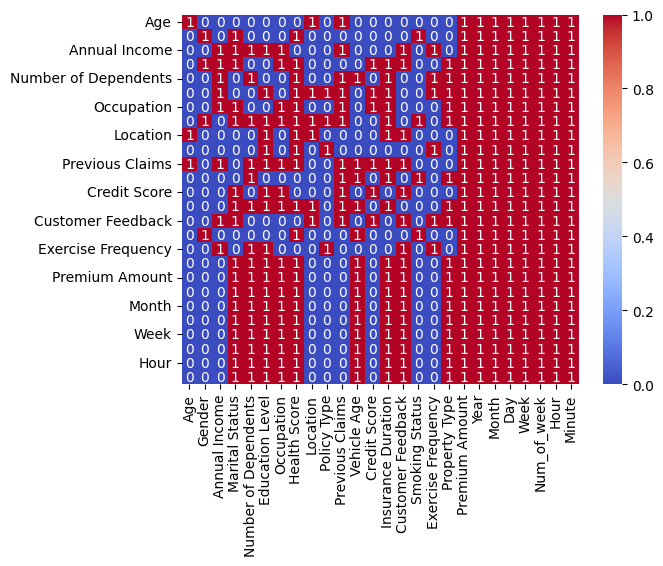

In [27]:
import seaborn as sns
sns.heatmap(final_df,annot=True,cmap="coolwarm")

In [28]:
for i in continues:
  print(i,"Skew :",df[i].skew(),"Kurtosis",df[i].kurtosis())

Age Skew : -0.012124039077023422 Kurtosis -1.1663719030495063
Annual Income Skew : 1.5229537478396937 Kurtosis 2.016891197172637
Health Score Skew : 0.3073021274990332 Kurtosis -0.6348953667048627
Credit Score Skew : -0.12578590724748864 Kurtosis -0.8414241913235956


In [29]:
for i in continues:
    if (df[i].skew() < 0.5 and df[i].skew() > -0.5) and (df[i].kurtosis() < 3 and df[i].kurtosis() > -3):
        continue
    print(i)

Annual Income


In [30]:
for i in continues:
    if (df[i].skew() < 0.5 and df[i].skew() > -0.5) and (df[i].kurtosis() < 3 and df[i].kurtosis() > -3):
        continue
    print(i)
    method = [1,-1,0,0.5,-0.5,2,-2]
    for j in method:
        print("Method",j,"Skew",pd.DataFrame(stats.boxcox(df[i],lmbda=j)).skew().values,"Kurtosis",pd.DataFrame(stats.boxcox(df[i],lmbda=j)).kurtosis().values)

Annual Income
Method 1 Skew [1.52295375] Kurtosis [2.0168912]
Method -1 Skew [-113.46016402] Kurtosis [30085.74576986]
Method 0 Skew [-1.04955485] Kurtosis [1.45537946]
Method 0.5 Skew [0.49718492] Kurtosis [-0.25847362]
Method -0.5 Skew [-9.85489349] Kurtosis [202.19241183]
Method 2 Skew [2.93478832] Kurtosis [8.94496845]
Method -2 Skew [-663.46841922] Kurtosis [546617.58773856]


In [31]:
df["Annual Income"] = stats.boxcox(df["Annual Income"],lmbda=0.5)

In [32]:
from sklearn.model_selection import train_test_split

x = df.drop(columns=['Premium Amount'])
y = np.log1p(df['Premium Amount'])
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [33]:
from category_encoders import TargetEncoder

cols = ["Gender","Marital Status","Education Level","Occupation",
        "Location","Policy Type","Customer Feedback",
        "Smoking Status","Exercise Frequency","Property Type"]

encoders = {}

from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for col in cols:
    x_train[col + "_te"] = 0
    
    for train_idx, val_idx in kf.split(x_train):
        tar = TargetEncoder(smoothing=10)
        tar.fit(x_train.iloc[train_idx][col], y_train.iloc[train_idx])
        x_train.iloc[val_idx, x_train.columns.get_loc(col + "_te")] = \
            tar.transform(x_train.iloc[val_idx][col])
    
    tar.fit(x_train[col], y_train)
    x_test[col + "_te"] = tar.transform(x_test[col])

x_train.drop(columns=cols, inplace=True)
x_test.drop(columns=cols, inplace=True)

encoders[col]=tar

In [34]:
df["claims_per_year"] = df["Previous Claims"] / (df["Insurance Duration"] + 1)
df["income_age"] = df["Annual Income"] * df["Age"]
df["age_group"] = pd.cut(df["Age"], bins=[18,25,35,50,65,100], labels=False)
df["credit_score_sq"] = df["Credit Score"] ** 2

In [35]:
df.isnull().sum()

Age                         0
Gender                      0
Annual Income               0
Marital Status              0
Number of Dependents        0
Education Level             0
Occupation                  0
Health Score                0
Location                    0
Policy Type                 0
Previous Claims             0
Vehicle Age                 0
Credit Score                0
Insurance Duration          0
Customer Feedback           0
Smoking Status              0
Exercise Frequency          0
Property Type               0
Premium Amount              0
Year                        0
Month                       0
Day                         0
Week                        0
Num_of_week                 0
Hour                        0
Minute                      0
claims_per_year             0
income_age                  0
age_group               24488
credit_score_sq             0
dtype: int64

In [36]:
impute_values1 = {"age_group": df["age_group"].median()}

In [37]:
df.fillna(impute_values1,inplace=True)

In [38]:
df.head()

,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount,Year,Month,Day,Week,Num_of_week,Hour,Minute,claims_per_year,income_age,age_group,credit_score_sq
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,19.0,0.0,198.489401,1.0,1.0,0.0,1.0,22.598761,2.0,2.0,2.0,17.0,372.0,5.0,2.0,0.0,3.0,2.0,2869.0,2023,12,23,51,5,15,21,0.333333,3771.298623,0.0,138384.0
1,39.0,0.0,353.966291,0.0,3.0,2.0,0.0,15.569731,0.0,1.0,1.0,12.0,694.0,2.0,0.0,1.0,1.0,2.0,1483.0,2023,6,12,24,0,15,21,0.333333,13804.685331,2.0,481636.0
2,23.0,1.0,318.012500,0.0,3.0,1.0,1.0,47.177549,1.0,2.0,1.0,14.0,595.0,3.0,1.0,1.0,3.0,2.0,567.0,2023,9,30,39,5,15,21,0.250000,7314.287494,0.0,354025.0
3,21.0,1.0,751.272859,1.0,2.0,0.0,0.0,10.938144,0.0,0.0,1.0,0.0,367.0,1.0,2.0,1.0,0.0,0.0,765.0,2024,6,12,24,2,15,21,0.500000,15776.730038,0.0,134689.0
4,21.0,1.0,396.251177,2.0,1.0,0.0,1.0,20.376094,0.0,2.0,0.0,8.0,598.0,4.0,2.0,1.0,3.0,2.0,2022.0,2021,12,1,48,2,15,21,0.000000,8321.274717,0.0,357604.0


In [39]:
x_train.head()

,Age,Annual Income,Number of Dependents,Health Score,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Year,Month,Day,Week,Num_of_week,Hour,Minute,Gender_te,Marital Status_te,Education Level_te,Occupation_te,Location_te,Policy Type_te,Customer Feedback_te,Smoking Status_te,Exercise Frequency_te,Property Type_te
id,,,,,,,,,,,,,,,,,,,,,,,,,
404339,45.0,602.367438,3.0,43.926883,1.0,1.0,311.0,2.0,2024,8,11,32,6,15,21,1,0,0,0,2,1,2,0,2,2
748487,51.0,143.327217,1.0,41.854227,1.0,1.0,634.0,8.0,2020,6,20,25,5,15,21,0,1,3,0,0,0,2,1,1,1
435951,48.0,404.536591,0.0,51.750192,1.0,12.0,759.0,9.0,2021,2,5,5,4,15,21,0,0,2,0,2,1,2,1,2,1
311284,43.0,346.551287,0.0,20.666786,2.0,8.0,460.0,1.0,2022,11,11,45,4,15,21,0,0,3,2,2,1,0,0,1,1
318790,18.0,225.077079,2.0,36.995102,1.0,18.0,831.0,3.0,2021,1,1,53,4,15,21,1,1,0,0,2,0,2,1,1,0


In [40]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor().fit(x_train,y_train)

In [41]:
test = pd.read_csv("test.csv")
test.head()

,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type
0,1200000,28.0,Female,2310.0,NaN,4.0,Bachelor's,Self-Employed,7.657981,Rural,Basic,NaN,19.0,NaN,1.0,2023-06-04 15:21:39.245086,Poor,Yes,Weekly,House
1,1200001,31.0,Female,126031.0,Married,2.0,Master's,Self-Employed,13.381379,Suburban,Premium,NaN,14.0,372.0,8.0,2024-04-22 15:21:39.224915,Good,Yes,Rarely,Apartment
2,1200002,47.0,Female,17092.0,Divorced,0.0,PhD,Unemployed,24.354527,Urban,Comprehensive,NaN,16.0,819.0,9.0,2023-04-05 15:21:39.134960,Average,Yes,Monthly,Condo
3,1200003,28.0,Female,30424.0,Divorced,3.0,PhD,Self-Employed,5.136225,Suburban,Comprehensive,1.0,3.0,770.0,5.0,2023-10-25 15:21:39.134960,Poor,Yes,Daily,House
4,1200004,24.0,Male,10863.0,Divorced,2.0,High School,Unemployed,11.844155,Suburban,Premium,NaN,14.0,755.0,7.0,2021-11-26 15:21:39.259788,Average,No,Weekly,House


In [42]:
test["Policy Start Date"] = pd.to_datetime(test["Policy Start Date"],format="%Y-%m-%d %H:%M:%S.%f")
test["Year"] = test["Policy Start Date"].dt.year
test["Month"] = test["Policy Start Date"].dt.month
test["Day"] = test["Policy Start Date"].dt.day
test["Week"] = test["Policy Start Date"].dt.isocalendar().week
test["Num_of_week"]=test["Policy Start Date"].dt.day_of_week
test["Hour"] = test["Policy Start Date"].dt.hour
test["Minute"] = test["Policy Start Date"].dt.minute
test["claims_per_year"] = test["Previous Claims"] / (test["Insurance Duration"] + 1)
test["income_age"] = test["Annual Income"] * test["Age"]
test["age_group"] = pd.cut(test["Age"], bins=[18,25,35,50,65,100], labels=False)
test["credit_score_sq"] = test["Credit Score"] ** 2

In [43]:
test.drop("Policy Start Date",axis=1,inplace=True)

In [44]:
test.isnull().sum()

id                           0
Age                      12489
Gender                       0
Annual Income            29860
Marital Status           12336
Number of Dependents     73130
Education Level              0
Occupation              239125
Health Score             49449
Location                     0
Policy Type                  0
Previous Claims         242802
Vehicle Age                  3
Credit Score             91451
Insurance Duration           2
Customer Feedback        52276
Smoking Status               0
Exercise Frequency           0
Property Type                0
Year                         0
Month                        0
Day                          0
Week                         0
Num_of_week                  0
Hour                         0
Minute                       0
claims_per_year         242803
income_age               41868
age_group                28640
credit_score_sq          91451
dtype: int64

In [45]:
test["claims_per_year"] = test["claims_per_year"].fillna(test["claims_per_year"].median())
test["income_age"] = test["income_age"].fillna(test["income_age"].median())
test["age_group"] = test["age_group"].fillna(test["age_group"].median())
test["credit_score_sq"] = test["credit_score_sq"].fillna(test["credit_score_sq"].median())

In [46]:
test.fillna(impute_values, inplace=True)
test.fillna(impute_values1,inplace=True)

In [47]:
print(encoders.keys())

dict_keys(['Property Type'])


In [48]:
test.set_index("id",inplace=True)

In [49]:
test = test.reindex(columns=x_train.columns, fill_value=0)

In [50]:
(x_train.columns == test.columns).all()

np.True_

In [51]:
y_pred = model.predict(x_test)
y_pred

array([6.1717006 , 6.7129562 , 6.22257627, ..., 4.4543473 , 7.70436117,
       7.19142933], shape=(240000,))

In [52]:
#test.head()

In [53]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((960000, 25), (240000, 25), (960000,), (240000,))

In [54]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [55]:
#from sklearn.tree import DecisionTreeRegressor
#model = DecisionTreeRegressor().fit(x_train,y_train)
#y_pred = model.predict(x_test)
#print("MSE:", mean_squared_error(y_test, y_pred))
#print("MAE:", mean_absolute_error(y_test, y_pred))
#print("R2 Score:", r2_score(y_test, y_pred))

In [56]:
#from sklearn.ensemble import GradientBoostingRegressor
#model = GradientBoostingRegressor().fit(x_train, y_train)
#y_pred = model.predict(x_test)
#print("MSE:", mean_squared_error(y_test, y_pred))
#print("MAE:", mean_absolute_error(y_test, y_pred))
#print("R2 Score:", r2_score(y_test, y_pred))

In [57]:
from xgboost import XGBRegressor
model = XGBRegressor().fit(x_train, y_train)
y_pred = model.predict(x_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 1.1135868553571862
MAE: 0.7499507540928549
R2 Score: 0.07364779308338076


In [58]:
from lightgbm import LGBMRegressor
model = LGBMRegressor().fit(x_train, y_train)
y_pred = model.predict(x_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028425 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 996
[LightGBM] [Info] Number of data points in the train set: 960000, number of used features: 23
[LightGBM] [Info] Start training from score 6.593848
MSE: 1.1073041493601448
MAE: 0.7470527830343979
R2 Score: 0.07887414658941316


In [59]:
from catboost import CatBoostRegressor
model = CatBoostRegressor().fit(x_train, y_train)
y_pred = model.predict(x_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Learning rate set to 0.121165
0:	learn: 1.0899489	total: 392ms	remaining: 6m 31s
1:	learn: 1.0855349	total: 563ms	remaining: 4m 40s
2:	learn: 1.0820469	total: 787ms	remaining: 4m 21s
3:	learn: 1.0786779	total: 946ms	remaining: 3m 55s
4:	learn: 1.0764954	total: 1.19s	remaining: 3m 57s
5:	learn: 1.0747425	total: 1.43s	remaining: 3m 57s
6:	learn: 1.0718663	total: 1.58s	remaining: 3m 44s
7:	learn: 1.0701983	total: 1.73s	remaining: 3m 34s
8:	learn: 1.0691836	total: 1.85s	remaining: 3m 23s
9:	learn: 1.0679124	total: 1.98s	remaining: 3m 16s
10:	learn: 1.0672627	total: 2.11s	remaining: 3m 9s
11:	learn: 1.0653967	total: 2.26s	remaining: 3m 6s
12:	learn: 1.0649016	total: 2.38s	remaining: 3m
13:	learn: 1.0642690	total: 2.52s	remaining: 2m 57s
14:	learn: 1.0639329	total: 2.63s	remaining: 2m 52s
15:	learn: 1.0626409	total: 2.9s	remaining: 2m 58s
16:	learn: 1.0615768	total: 3.16s	remaining: 3m 2s
17:	learn: 1.0607466	total: 3.37s	remaining: 3m 3s
18:	learn: 1.0600782	total: 3.65s	remaining: 3m 8s
19

In [60]:
#from sklearn.ensemble import AdaBoostRegressor
#model = AdaBoostRegressor().fit(x_train, y_train)
#y_pred = model.predict(x_test)
#print("MSE:", mean_squared_error(y_test, y_pred))
#print("MAE:", mean_absolute_error(y_test, y_pred))
#print("R2 Score:", r2_score(y_test, y_pred))

In [61]:
df['Premium Amount'].describe()

count    1.200000e+06
mean     1.102545e+03
std      8.649989e+02
min      2.000000e+01
25%      5.140000e+02
50%      8.720000e+02
75%      1.509000e+03
max      4.999000e+03
Name: Premium Amount, dtype: float64

In [63]:
model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)

model.fit(x_train, y_train)
y_pred = model.predict(x_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025188 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 996
[LightGBM] [Info] Number of data points in the train set: 960000, number of used features: 23
[LightGBM] [Info] Start training from score 6.593848
MSE: 1.1084880137684003
MAE: 0.747827602077582
R2 Score: 0.07788933305466128


In [64]:
from sklearn.model_selection import RandomizedSearchCV

In [65]:
param_grid = {
    "n_estimators": [300, 500, 800],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0]
}

<BarContainer object of 25 artists>

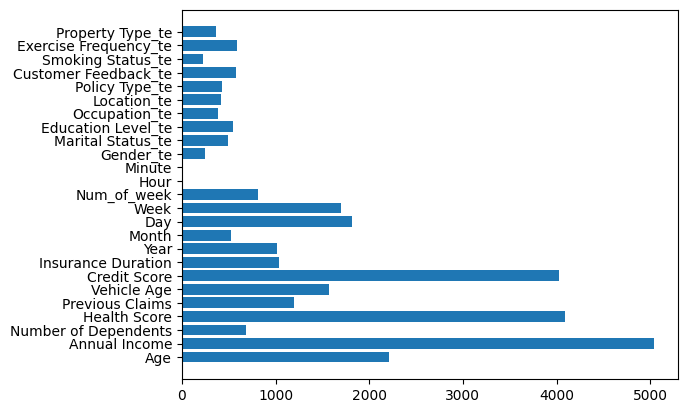

In [66]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
plt.barh(x_train.columns, importance)

In [67]:
drop_cols = [
    "Property Type_te",
    "Exercise Frequency_te",
    "Smoking Status_te",
    "Gender_te",
    "Minute",
    "Hour",
    "Location_te",
    "Occupation_te"
    "Customer Feedback_te",
    "Policy Type_te",
]

In [68]:
x_train_lgb = x_train.drop(columns=drop_cols, errors='ignore')
x_test_lgb = x_test.drop(columns=drop_cols, errors='ignore')

In [69]:
from lightgbm import LGBMRegressor

lgb = LGBMRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=5
)

lgb.fit(x_train_lgb, y_train)

y_pred = lgb.predict(x_test_lgb)

from sklearn.metrics import r2_score
print("R2:", r2_score(y_test, y_pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.054612 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 979
[LightGBM] [Info] Number of data points in the train set: 960000, number of used features: 17
[LightGBM] [Info] Start training from score 6.593848
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

In [70]:
y = df['Premium Amount']

In [71]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, x, y, cv=5, scoring='r2')
print(scores.mean())

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.104293 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 995
[LightGBM] [Info] Number of data points in the train set: 960000, number of used features: 23
[LightGBM] [Info] Start training from score 1102.201561
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026308 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 994
[LightGBM] [Info] Number of data points in the train set: 960000, number of used features: 23
[LightGBM] [Info] Start training from score 1102.493631
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] 